# Classification with Synthetic Data

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from keras import layers, Sequential

## 1- Data Preparation

### Create a Dataset

In [12]:
N_CLASSES = 3
CLASS_NAMES = ["A", "B", "C"]

In [13]:
X_raw, y_raw = make_blobs(
    n_samples = 600,
    centers = [[-3, -3], [3, 0], [0, 4]],
    cluster_std = [1.2, 1.0, 1.1],
    random_state = 42
)
X_raw = X_raw + np.random.randn(*X_raw.shape) * 0.3

In [14]:
X_raw.shape

(600, 2)

In [15]:
y_raw.shape

(600,)

In [16]:
print('First sample:', X_raw[0])
print('Class of the first sample:', y_raw[0])

First sample: [-2.94189611 -2.55180658]
Class of the first sample: 0


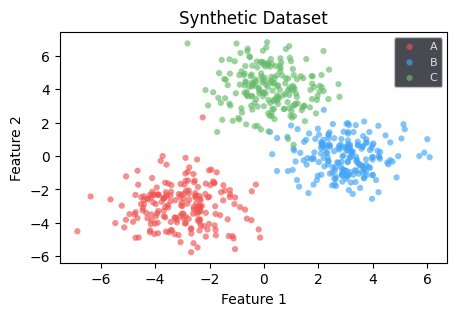

In [26]:
plt.figure(figsize=(5,3))
COLORS = ["#EF5350", "#42A5F5", "#66BB6A"]  # قرمز / آبی / سبز
for c, name, col in zip(range(N_CLASSES), CLASS_NAMES, COLORS):
    mask = y_raw == c
    plt.scatter(X_raw[mask, 0], X_raw[mask, 1], s=20, alpha=0.65,
                color=col, label=name, edgecolors="none")
plt.title("Synthetic Dataset")
plt.xlabel("Feature 1");
plt.ylabel("Feature 2")
plt.legend(fontsize=8, facecolor="#1a1d27", labelcolor="#e0e0e0")
plt.show()

### Prepare data for training

In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y_raw, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)
print(f"\n• Train={len(X_train)}  Val={len(X_val)}  Test={len(X_test)}")


• Train=420  Val=90  Test=90


### Data scaling (normalization)

In [38]:
#  Important tip: Only fit the scaler on the train set (not val or test)
scaler_x = StandardScaler()

X_train_s = scaler_x.fit_transform(X_train)
X_val_s = scaler_x.transform(X_val)
X_test_s = scaler_x.transform(X_test)

## 2- Model Design

In [31]:
model = Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,387 (17.14 KB)

 Trainable params: 4,387 (17.14 KB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

In [35]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [39]:
history = model.fit(X_train_s, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_val_s, y_val))

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5405 - loss: 0.9728 - val_accuracy: 0.9111 - val_loss: 0.8330
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9476 - loss: 0.7676 - val_accuracy: 0.9333 - val_loss: 0.6302
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9619 - loss: 0.5726 - val_accuracy: 0.9667 - val_loss: 0.4400
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.3992 - val_accuracy: 0.9778 - val_loss: 0.2984
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9810 - loss: 0.2625 - val_accuracy: 0.9889 - val_loss: 0.1963
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9857 - loss: 0.1580 - val_accuracy: 0.9889 - val_loss: 0.1262
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9881 - loss: 0.0918 - val_accuracy: 0.9889 - val_loss: 0.0883
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9905 - loss: 0.0613 - val_accuracy: 0.9889 - 

## 4- Evaluation

### Numerical Metrics

In [40]:
val_loss, val_accuracy = model.evaluate(X_val_s, y_val)
print(f'Loss (validation): {val_loss:.4f}')
print(f'Accuracy (validation): {val_accuracy:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9889 - loss: 0.1001    
Loss (validation): 0.1001
Accuracy (validation): 0.9889


In [55]:
y_prob = model.predict(X_test_s)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [56]:
y_pred = np.argmax(y_prob, axis=1)

In [61]:
acc_test = np.mean(y_pred == y_test)
c_report = classification_report(y_test, y_pred)
print(f"🎯 Accuracy (Test): {acc_test*100:.2f}%\n")
print(c_report)

🎯 Accuracy (Test): 97.78%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.94      0.97        34
           2       0.95      1.00      0.97        35

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



### Visualizations

In [87]:
# ─── نمودارها ─────────────────────────────────────────────
COLORS = ["#EF5350", "#42A5F5", "#66BB6A"]  # قرمز / آبی / سبز
CMAP_LIGHT = ListedColormap(["#FFCDD2", "#BBDEFB", "#C8E6C9"])
CMAP_BOLD  = ListedColormap(COLORS)

fig = plt.figure(figsize=(20, 16), facecolor="#0f1117")
fig.suptitle("Clasification with Synthetic Data",
             fontsize=18, color="white", y=0.98, fontweight="bold")
gs = gridspec.GridSpec(2, 6, hspace=0.38, wspace=0.32)

def ax_style(ax):
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#e0e0e0", labelsize=9)
    for sp in ax.spines.values():
        sp.set_color("#2a2d3a")
    ax.xaxis.label.set_color("#e0e0e0")
    ax.yaxis.label.set_color("#e0e0e0")
    ax.title.set_color("#e0e0e0")

# ── داده‌های خام (واقعی) ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
ax_style(ax1)
for c, name, col in zip(range(N_CLASSES), CLASS_NAMES, COLORS):
    mask = y_raw == c
    ax1.scatter(X_raw[mask, 0], X_raw[mask, 1], s=20, alpha=0.65,
                color=col, label=name, edgecolors="none")
ax1.set_title("Input Data (All samples)")
ax1.set_xlabel("Feature 1"); ax1.set_ylabel("Feature 2")
ax1.legend(fontsize=8, facecolor="#1a1d27", labelcolor="#e0e0e0")

# ── سطح تصمیم مدل (decision boundary) ──────────────────
ax2 = fig.add_subplot(gs[0, 2:4])
ax_style(ax2)
# شبکه‌ی فضای ویژگی
pad = 1.5
x1_min, x1_max = X_raw[:, 0].min()-pad, X_raw[:, 0].max()+pad
x2_min, x2_max = X_raw[:, 1].min()-pad, X_raw[:, 1].max()+pad
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid = np.c_[xx1.ravel(), xx2.ravel()]
grid_s = scaler_x.transform(grid)
Z = np.argmax(model.predict(grid_s, verbose=0, batch_size=512), axis=1)
Z = Z.reshape(xx1.shape)

ax2.contourf(xx1, xx2, Z, alpha=0.35,
             cmap=ListedColormap(["#FFCDD2","#BBDEFB","#C8E6C9"]))
ax2.contour(xx1, xx2, Z, colors=["#EF5350","#42A5F5","#66BB6A"],
            linewidths=1.2, alpha=0.8)
for c, name, col in zip(range(N_CLASSES), CLASS_NAMES, COLORS):
    mask = y_test == c
    ax2.scatter(X_test[mask, 0], X_test[mask, 1], s=25,
                alpha=0.8, color=col, edgecolors="white", lw=0.3,
                label=name)
ax2.set_title(f"Decision Boundary (Test) — Acc={acc_test*100:.1f}%")
ax2.set_xlabel("Feature 1"); ax2.set_ylabel("Feature 2")
ax2.legend(fontsize=8, facecolor="#1a1d27", labelcolor="#e0e0e0")

# ── confusion matrix ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 4:6])
ax_style(ax3)
cm = confusion_matrix(y_test, y_pred)
im = ax3.imshow(cm, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax3, fraction=0.046)
ticks = range(N_CLASSES)
ax3.set_xticks(ticks); ax3.set_yticks(ticks)
ax3.set_xticklabels(["A","B","C"], color="#e0e0e0")
ax3.set_yticklabels(["A","B","C"], color="#e0e0e0")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax3.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "#0f1117",
                 fontsize=13, fontweight="bold")
ax3.set_xlabel("Predicted"); ax3.set_ylabel("Real")
ax3.set_title("③ Confusion Matrix (Test)")

# ── منحنی یادگیری — Loss ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:3])
ax_style(ax4)
ep = range(1, len(history.history["loss"]) + 1)
ax4.plot(ep, history.history["loss"],     color="#FFD54F", lw=2, label="Train Loss")
ax4.plot(ep, history.history["val_loss"], color="#EF9A9A", lw=2,
         linestyle="--", label="Val Loss")
ax4.set_title("Loss Plot (Cross-Entropy)")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Cross-Entropy")
ax4.set_ylim([0, 0.3])
ax4.legend(fontsize=8, facecolor="#1a1d27", labelcolor="#e0e0e0")

# ── منحنی یادگیری — Accuracy ───────────────────────────
ax5 = fig.add_subplot(gs[1, 3:6])
ax_style(ax5)
ax5.plot(ep, history.history["accuracy"],     color="#80CBC4", lw=2, label="Train Acc")
ax5.plot(ep, history.history["val_accuracy"], color="#CE93D8", lw=2,
         linestyle="--", label="Val Acc")
ax5.axhline(acc_test, color="#FF7043", lw=1.5, linestyle=":", label=f"Test Acc={acc_test:.3f}")
ax5.set_title("Accuracy Plot")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Accuracy")
ax5.legend(fontsize=8, facecolor="#1a1d27", labelcolor="#e0e0e0")
ax5.set_ylim([0.9, 1.01])

plt.savefig("synthetic_classification_report.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.close()
print("✅ نمودارهای کلاسیفیکیشن ذخیره شد.")

✅ نمودار کلاسیفیکیشن ذخیره شد.
